# MacKenzie Scott’s giving, in QALYs

An evidence-weighted, auditable cost-effectiveness model of a \$26 billion portfolio

\| [Max Ghenis]()

MacKenzie Scott has disclosed \$26.39 billion in gifts to more than 2,500 organizations since 2019 — her 2025 giving alone was about a third of the value of that year’s U.S. megagifts — yet almost none of it is denominated in outcomes. This paper prices the entire portfolio in quality-adjusted life-years. A Monte Carlo model allocates dollars across 14 intervention archetypes using Scott’s own gift-level database, imputes the undisclosed third from recipients’ pre-gift IRS 990 revenue, assigns each archetype a cost-per-QALY anchor from published causal estimates, and shrinks every effect toward zero in proportion to the causal credibility of its evidence. The best-guess estimate is a median of roughly 202,000 QALYs (90% interval 94,000–419,000), a blended \$150,000 per QALY, and a median benefit–cost ratio of 4.9 under the valuation distribution HHS uses for regulatory analysis. Three findings follow. First, estimated impact is geographically concentrated: the 4.8% of dollars funding health and development delivered outside the United States, priced at global-health anchors, accounts for 69% of estimated health impact. Second, gift size scales with recipient size to only the 0.41 power — a 10× larger organization receives about 2.5× more money. Third, the answer is dominated by evidence philosophy rather than arithmetic: restricting credit almost entirely to randomized evidence collapses the median to ~9,000 QALYs while taking every study at near face value raises it to ~415,000 — a 45× range, larger than the spread from any single distributional parameter tested. All parameters, code, data snapshots, and an AI-audit trail are public, and the model runs interactively in the browser.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import yaml

ROOT = Path.cwd().resolve()
if not (ROOT / "results").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

S = json.loads((ROOT / "results" / "summary.json").read_text())
GEO = json.loads((ROOT / "web" / "geo.json").read_text())
V10 = json.loads((ROOT / "web" / "allocation_v10.json").read_text())
V11 = json.loads((ROOT / "web" / "allocation_v11.json").read_text())
P = yaml.safe_load((ROOT / "data" / "parameters.yaml").read_text())

from msqaly.allocation import derive_shares
_, DIAG = derive_shares()

tq = S["total_qalys"]
def k(x): return f"{x/1000:,.0f},000" if x >= 10000 else f"{x:,.0f}"
def kk(x): return f"{round(x/1000):,}k"
def usd(x):
    if abs(x) >= 0.9995e9: return f"${x/1e9:,.2f}B"
    if abs(x) >= 0.9995e6: return f"${x/1e6:,.0f}M"
    return f"${x:,.0f}"

F = dict(
    median=f"{tq['median']:,.0f}",
    median_k=k(tq['median']),
    mean=f"{tq['mean']:,.0f}",
    p05=k(tq['p05']), p95=k(tq['p95']),
    blended=f"${S['blended_cost_per_qaly_median']:,.0f}",
    giving=f"${S['total_giving_usd']/1e9:,.1f}B",
    frontier_mult=f"{S['frontier_multiple_median']:,.0f}",
    frontier_q=f"{S['frontier_qalys_median']/1e6:,.1f} million",
    elasticity=f"{DIAG['elasticity']:.2f}",
    r2=f"{DIAG['elasticity_r2']:.2f}",
    n_cal=f"{DIAG['n_calibration']:,}",
    n_orgs=f"{DIAG['n_orgs']:,}",
    n_gifts=f"{DIAG['n_gifts']:,}",
    n_disclosed=f"{DIAG['n_disclosed']:,}",
    disclosed_b=f"${DIAG['disclosed_usd']/1e9:,.2f}B",
    imputed_b=f"${DIAG['imputed_usd']/1e9:,.2f}B",
    abroad_share=f"{100*DIAG['raw_shares']['global_health']:.2f}%",
    abroad_share_1=f"{100*DIAG['raw_shares']['global_health']:.1f}%",
)

per = S["per_archetype_mean"]
mean_total = sum(per.values())
gh_label = [kb for kb in per if "Global health" in kb][0]
F["gh_share"] = f"{100*per[gh_label]/mean_total:.1f}%"
F["gh_mean"] = f"{per[gh_label]:,.0f}"
F["bc"] = f"{S['bc_ratio']['median']:.1f}"
F["bc_p05"] = f"{S['bc_ratio']['p05']:.1f}"
F["bc_p95"] = f"{S['bc_ratio']['p95']:.1f}"

# Disclosed dollars to organizations reporting non-US service locations,
# under the audited us_share overlay (and under the raw rule, for contrast).
from msqaly.allocation import load_geo_overlay, nonus_fraction
_overlay = load_geo_overlay()
_orgs_raw = json.loads((ROOT / "data" / "yieldgiving" / "organisations.json").read_text())
_ab_audit = _ab_raw = _disc = 0.0
for _o in _orgs_raw:
    _usd = sum(g.get("amount") or 0 for g in _o.get("gifts", []))
    if not _usd or not _o.get("locations"):
        continue
    _disc += _usd
    _raw = nonus_fraction(_o.get("locations"))
    _ab_raw += _usd * _raw
    _ab_audit += _usd * _overlay.get(_o["name"], _raw)
F["abroad_disc_audited_b"] = f"${_ab_audit/1e9:,.2f}B"
F["abroad_disc_audited_pct"] = f"{100*_ab_audit/_disc:.0f}%"
F["abroad_disc_raw_pct"] = f"{100*_ab_raw/_disc:.1f}%"

# Region mix of the routed global-health bucket (from the archetype matrix).
_ghm = GEO["archetype_region_matrix"]["matrix"]["global_health"]
F["gh_ssa"] = f"{100*_ghm.get('sub-_saharan_africa', 0):.0f}%"
F["gh_sasia"] = f"{100*_ghm.get('south_asia', 0):.0f}%"
F["gh_latam"] = f"{100*_ghm.get('latin_america&_caribbean', 0):.0f}%"
F["gh_unattrib"] = f"{100*_ghm.get('global', 0):.0f}%"
F["gh_hic"] = f"{100*(_ghm.get('europe&_central_asia', 0) + _ghm.get('canada', 0)):.0f}%"

# Introduction

MacKenzie Scott gave away \$7.17 billion in 2025 \[@cnbc2025scott\]; Giving USA counts \$6.65 billion of it against \$19.2 billion in U.S. megagift dollars — about a third of that year’s megagift value \[@givingusa2026; @ap2026givingusa\]. (The bases differ: Yield Giving’s own annual total is the larger figure.) Her disclosed lifetime total is \$26.39 billion across 2,711 gifts to 2,545 organizations since 2019 \[@yieldgiving2026\]. Almost none of it is denominated in health, and, to my knowledge, no published estimate prices the portfolio in outcomes of any kind.

This paper does so in the unit health economists use to compare a death averted against years lived in better health: the quality-adjusted life-year. The exercise is deliberately in the style of a charity evaluator’s cost-effectiveness analysis \[@givewell2026impact\], scaled from a program to a portfolio, with one addition the setting forces: because most of the portfolio funds interventions whose health effects have never been causally measured, the model makes its epistemics explicit. Every effect is shrunk toward zero in proportion to how well its supporting study identifies causation, the shrinkage schedule is a slider rather than a buried constant, and the headline is reported across the full range of evidence philosophies — from counting only randomized evidence to taking every published estimate at face value.

The paper makes four contributions. It provides what I believe is the first outside, portfolio-level cost-effectiveness estimate of Scott’s giving, and I have found no comparable outside estimate for any other individual mega-donor — funder-run portfolio metrics exist, including GiveWell’s aggregate impact estimates \[@givewell2026impact\], Robin Hood’s benefit–cost framework \[@robinhood2025\], the Constellation Fund’s portfolio reporting \[@constellation2025\], and social-rate-of-return analysis of USAID’s Development Innovation Ventures portfolio \[@cega2023div\]; the difference here is independence from the donor, a subject who publishes no outcome data, and explicit evidence weighting: a best-guess median of 202,000 QALYs from \$26.39 billion nominal (\$30.3B in 2026 dollars), a blended \$150,067 per QALY, and a median benefit–cost ratio of 4.9 under the HHS regulatory value-per-QALY distribution \[@aspe2026values\]. It estimates extreme geographic concentration of impact under its pricing assumptions: the 4.8% of dollars funding global health and development delivered outside the United States accounts for 69.1% of estimated health impact. It reports a new empirical regularity in the gift data itself: across 1,313 disclosed gift–filing pairs, gift size scales with recipient pre-gift revenue to the power 0.41 (R² 0.37) — Scott’s giving is far flatter across organization size than proportional. And it demonstrates a working method for auditable, AI-assisted cost-effectiveness modeling: the model was built with a frontier language model, reviewed and corrected in public through the revision history summarized in the robustness section, audited by two independent model families against primary filings, and ships with versioned parameters, machine-checked citations, and a browser implementation that reruns the full Monte Carlo under any reader’s assumptions.

The unit of account deserves a caveat before any number. QALYs measure health. Most of Scott’s portfolio aims at other things — education, economic mobility, equity, civic infrastructure — whose primary benefits are not health benefits. A finding that a dollar of education philanthropy produces few QALYs is a statement about the lens, not a verdict on the gift. The estimates are a partial, health-only accounting under positive-effect priors — not a lower bound on total wellbeing: the lens omits the primary intended benefits of most of the portfolio, and the model places no probability on zero or harmful effects, a structural choice the limitations section returns to.

# Data

## The ledger

Scott’s essays disclose giving in dated tranches totaling \$26.39 billion nominal over 2020–2025. The model inflates each tranche — booked by disclosure year — to 2026 dollars (CPI-U, anchored to May 2026), so dollars and cost-effectiveness evidence share one price level: \$30.3B total. All derivations below, and the replication repository, start from a verbatim snapshot of the Yield Giving gift database retrieved July 11, 2026 \[@yieldgiving2026\].

## Allocation across causes

Scott publishes no aggregate dollars-by-cause breakdown, but she publishes something more granular: a gift-level database listing every recipient organization, its self-reported focus areas, and — for 2,035 of 2,711 gifts (\$17.46B, about two-thirds of the nominal total) — the dollar amount. Each organization’s dollars are split equally across its focus areas; the database’s 53 areas map onto the model’s 14 intervention archetypes under a documented, sync-tested crosswalk.

The undisclosed third is imputed rather than dropped. Because the essays give each year’s total, the undisclosed residual per period is a known dollar amount; it is distributed across that period’s undisclosed gifts in proportion to each recipient’s pre-gift IRS Form 990 total revenue \[@propublica2026\], raised to an elasticity fit on the disclosed pairs. Pre-gift means the latest filing strictly before the gift year, since a Scott gift mechanically inflates receipt-year revenue. The fit is a finding in its own right: across 1,313 disclosed gift–filing pairs, log gift size rises with log revenue with slope 0.41 (R² 0.37). A 10× larger organization receives about 2.5× more money, not 10× more. The fit is descriptive and conditional: it is estimated on disclosed gifts with a matched pre-gift filing (1,313 of 2,035 disclosed and 2,711 total gifts), treats repeated gifts to an organization as independent, and pools years; 287 of the 676 undisclosed gifts lack a usable filing and receive their period’s median weight. It is a within-sample regularity used for imputation, not a validated prediction rule. Fuzzy name-to-EIN matches were audited by a third, smaller model against the live IRS API, with corrections committed as a reviewable overlay. The imputed third moves each cause share by at most about 1.5 percentage points — under the imputation model, the disclosed two-thirds is representative.

## Delivery geography

Each organization reports service locations. Weighting disclosed dollars by the audited share of each organization’s locations outside the United States, an estimated 19% of disclosed dollars (\$3.34B of \$17.46B) sits with organizations reporting non-U.S. service locations — 20.4% under the raw rule that counts a bare “global” listing as fully non-U.S. — led by environment, health, and funding intermediaries. Locations are an equal-split proxy: a listed location is not an expenditure share, and no organization reports how Scott’s own gift was deployed. The model prices geography through a single channel: health-relevant dollars route to a global-health archetype in proportion to the recipient’s non-U.S. service share, because global health delivery is the one category with a published cost-per-QALY evidence base an order of magnitude below U.S. anchors. Education and climate dollars keep their U.S.-study anchors wherever they are delivered; if geography changes their effectiveness, the model does not capture it.

The coarsest geographic field is the bare label “global.” An audit of the 50 organizations with the most dollars attached to that label — 87% of its dollars; 20 of the 50 also list other locations — replaced the blanket assumption of fully-abroad delivery with fractions coded independently by two model families from each organization’s filings and program reports, then reconciled — the second coder confirmed 33 within tolerance and disputed 17; four disputes were adjudicated to documented filings arithmetic, and final fractions average the two coders everywhere else, with per-organization sources and confidence grades — 16 high, 17 medium, 17 low — committed to the repository. Many “global” organizations operate substantially in the United States: Planned Parenthood and Crisis Text Line, for example, list “global” service but are roughly 95% and 93% U.S. in their most recent organization-wide reporting — later-period proxies for how earlier gifts were deployed, since neither reports gift-level allocation. The audited allocation routes 4.82% of the ledger to the global health and development archetype. That routed bucket is itself mixed: its dollars sit 42% in Sub-Saharan Africa, 20% in South Asia, and 11% in Latin America, but 18% is unattributable multi-region activity and roughly 4% sits in Europe & Central Asia plus Canada — regions that are not classified by income here, so the bucket’s true high-income share is unidentified — all priced at the same low-and-middle-income anchors, a coarseness the limitations section flags.

# Model

Each Monte Carlo draw allocates the giving across archetypes (a Dirichlet centered on the derived shares), assigns each archetype a cost per QALY drawn from a distribution anchored in published estimates, and multiplies the implied QALYs by two independent discounts. **Causal credibility** asks whether the measured effect is real. Each archetype carries the identification tier of its best supporting evidence, and the tier sets a Beta-distributed shrinkage factor toward the null: a lottery-randomized wealth shock \[@cesarini2016wealth\] or the Medicaid mortality quasi-experiments — the ACA expansions \[@miller2021medicaid\], with cost–benefit arithmetic from the pre-ACA state expansions \[@sommers2017medicaid\] whose spending component draws on the Oregon Health Insurance Experiment \[@finkelstein2012oregon\] — keeps most of its effect; a child-targeted cash quasi-experiment \[@aizer2016cash\], with related designs catalogued in the parameter file, anchors the cash bucket; the community-health-center rollout design \[@bailey2015war\] and similar contested quasi-experiments keep less; associational and assumption-only categories are shrunk near zero. **Realization** asks whether a marginal philanthropic dollar delivers the studied effect at all — transport to different populations, overhead, and funging, net of possible capacity effects: surveyed Scott recipients report stronger capacity and reach \[@cep2023gifts\], self-reports on whose basis the model permits realization above one (an author judgment, not a CEP effect estimate). It is one global triangular draw with mode 0.80 on support 0.55–1.10.

The two multipliers are designed to partition the doubt — transportability concerns in realization, identification concerns in credibility, cost-per-QALY priors stated conditional on the effect being real and delivered — though the separation is imperfect at the prior boundaries: several anchors already average over mixed null-and-positive evidence before the credibility discount applies (a limitation noted below). Allocation uncertainty is a Dirichlet with concentration 60 around the derived centers — a judgment prior, implying for example a roughly 1.3–10% ninety-percent range on the global-health share — and represents subjective allocation uncertainty rather than sampling uncertainty propagated from the gift data pipeline. The tier ordering is the defensible part; the levels are judgment, proposed by a language model and reviewed by the author, and the results section reports the full consequence of disagreeing with them.

Health effects arrive in different natural units — lives saved, life-years, depression-free days — and are converted to discounted QALYs at a 3% annual rate under source-specific conventions: adult mortality anchors sample roughly 26 remaining life-years at a utility draw centered near 0.78, the frontier’s child-mortality benchmark uses a fixed ~65 remaining years at utility 0.87, and direct cost-per-QALY anchors keep their sources’ conventions. Every parameter’s unit and dollar vintage is machine-validated at load. The global-health frontier benchmark is handicapped within the same framework: GiveWell’s reported recent program averages \[@givewell2026impact\], converted to roughly \$175–\$241 per discounted QALY-equivalent under this model’s own conventions (a model conversion, not a GiveWell QALY figure), modeled as loguniform \$150–\$260, sharing each draw’s realization multiplier, and receiving RCT-grade credibility — the strongest tier — where portfolio archetypes receive their own.

# Results

In [2]:
tiers = {a: P["archetypes"][a].get("causal_credibility", "—") for a in P["archetypes"]}
labels = {a: P["archetypes"][a]["label"] for a in P["archetypes"]}
label_to_key = {v: k for k, v in labels.items()}
giving_usd = S["total_giving_usd"]
rows = []
for lab, q in sorted(per.items(), key=lambda kv: -kv[1]):
    key = label_to_key[lab]
    share = V11["allocation_share"][key]
    d = share * giving_usd
    rows.append({
        "Cause": lab,
        "Dollars": usd(d),
        "% of $": f"{100*share:.0f}%",
        "QALYs": f"{q:,.0f}",
        "% of QALYs": f"{100*q/mean_total:.0f}%" if q/mean_total >= 0.005 else "<1%",
        "$/QALY": usd(d/q) if q > 0 else "—",
        "Evidence": tiers[key],
    })
rows.append({"Cause": "Total", "Dollars": usd(giving_usd), "% of $": "100%",
             "QALYs": f"{mean_total:,.0f}", "% of QALYs": "100%",
             "$/QALY": usd(giving_usd/mean_total), "Evidence": ""})
cause_df = pd.DataFrame(rows)
ev_tiers = {"randomized", "strong_quasi", "moderate_quasi", "quasi_contested"}
ev_ratios = []
for lab, q in per.items():
    key = label_to_key[lab]
    if key == "global_health" or q <= 0:
        continue
    if any(t in str(tiers[key]) for t in ("randomized", "quasi")):
        ev_ratios.append(V11["allocation_share"][key] * giving_usd / q)
F2 = dict(
    gh_cpq=usd(V11["allocation_share"]["global_health"] * giving_usd / per[gh_label]),
    ev_lo=usd(min(ev_ratios)), ev_hi=usd(max(ev_ratios)),
    spread=f"{max(V11['allocation_share'][label_to_key[l]]*giving_usd/q for l, q in per.items() if q > 0) / min(V11['allocation_share'][label_to_key[l]]*giving_usd/q for l, q in per.items() if q > 0):,.0f}",
)

At the best-guess defaults (100,000 draws), the portfolio produces a median of 201,923 QALYs, with a 90% interval of 94,000 to 419,000 and a mean of 222,060. The interval is a probabilistic-sensitivity range under the stated priors, not a confidence interval; Monte Carlo error on the median is a few hundred QALYs. The blended cost-effectiveness — dollars given over QALYs produced, at the median — is \$150,067 per QALY. Monetized under the value-per-QALY distribution HHS recommends for regulatory analysis (central \$726,000 at 3%; @aspe2026values, Table 3), the median draw-level benefit–cost ratio is 4.9 (90% interval 2.1–11.0, reflecting both health-output and valuation uncertainty). @fig-dist shows the full distribution.

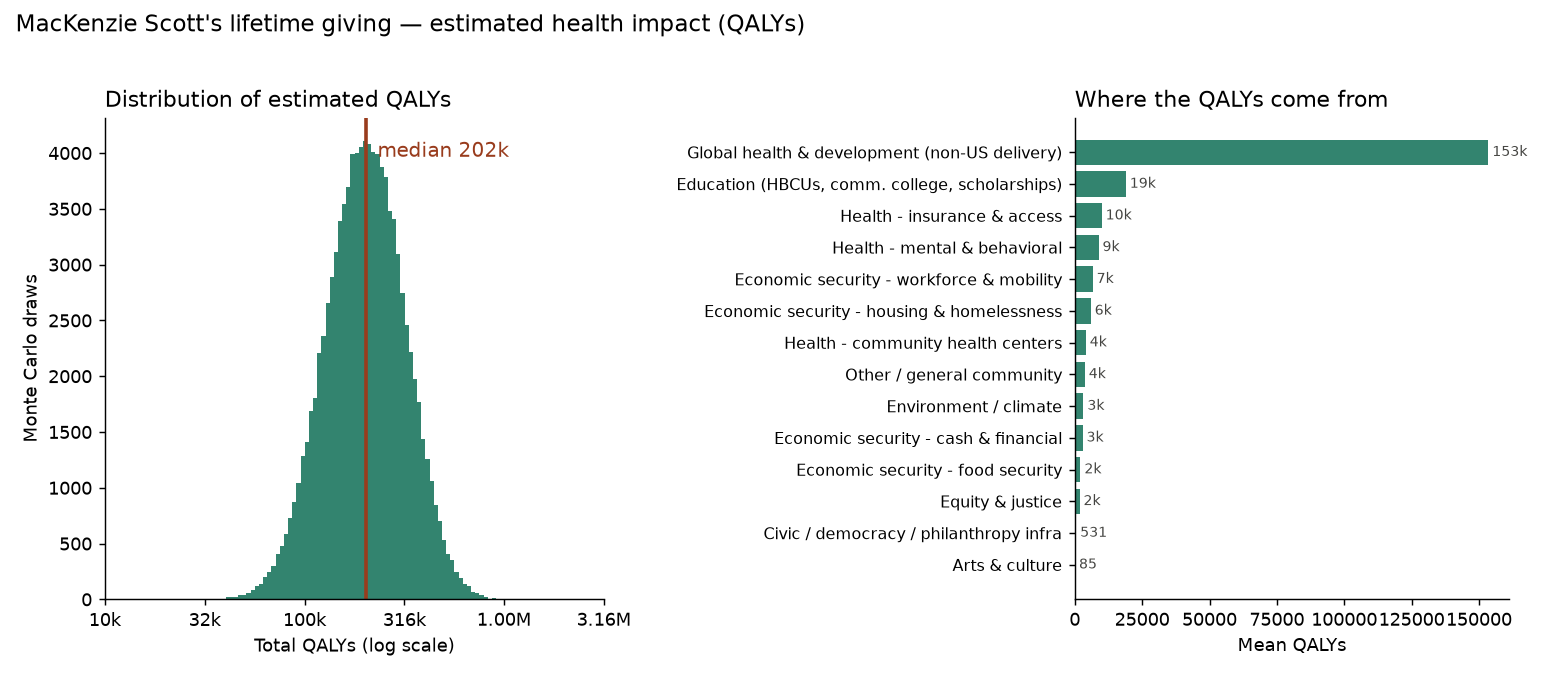

## Where it comes from

@tbl-cause decomposes the mean estimate by cause. The result is the paper’s central contrast: the global health and development slice — 4.8% of dollars — contributes 69.1% of estimated QALYs, at a modeled cost of about \$9,477 per QALY against \$75,673–\$305,164 for the causes with quasi-experimental or better U.S. evidence. The 1,278-fold spread in modeled cost-effectiveness within a single donor’s portfolio, under stipulated priors, is partly the lens speaking — its low end is dominated by assumption-tier buckets whose near-zero credibility is an input, and whose main benefits QALYs do not count — but the spread among evidenced health buckets alone exceeds an order of magnitude, restating in one column an empirical regularity long emphasized in the effective-altruism literature \[@ord2013\]: the cheapest health in the world is not bought where most philanthropic dollars are spent.

In [3]:
from IPython.display import Markdown
Markdown(cause_df.to_markdown(index=False))

In [4]:
M = GEO["archetype_region_matrix"]["matrix"]
region_meta = {r["key"]: r for r in GEO["archetype_region_matrix"]["regions"]}
acc = {}
for lab, q in per.items():
    key = label_to_key[lab]
    d = V11["allocation_share"][key] * giving_usd
    for region, w in M.get(key, {}).items():
        a = acc.setdefault(region, [0.0, 0.0])
        a[0] += d * w
        a[1] += q * w
geo_rows = []
for region, (d, q) in sorted(acc.items(), key=lambda kv: -kv[1][1]):
    meta = region_meta[region]
    geo_rows.append({
        "Region": meta["label"] + (" *" if meta["unspecified"] else ""),
        "Dollars": usd(d),
        "% of $": f"{100*d/giving_usd:.0f}%" if d/giving_usd >= 0.005 else "<1%",
        "QALYs": f"{q:,.0f}",
        "% of QALYs": f"{100*q/mean_total:.0f}%" if q/mean_total >= 0.005 else "<1%",
        "$/QALY": usd(d/q) if q > 0 else "—",
    })
geo_df = pd.DataFrame(geo_rows)
ssa = [r for r in geo_rows if "Sub-Saharan" in r["Region"]][0]
usnat = [r for r in geo_rows if "national" in r["Region"]][0]

@tbl-geo decomposes the same run by delivery geography. The table is a by-construction decomposition, not evidence of regional differences: within each cause the model prices every delivery location identically — the health routing to global anchors is its only geographic pricing — so a cause’s QALYs follow its dollars across regions. Under that construction, Sub-Saharan Africa receives 6% of dollars and 30% of estimated QALYs at \$27,031 per QALY; nationally-scoped U.S. giving receives 27% of dollars and 9% of QALYs at \$403,000.

In [5]:
Markdown(geo_df.to_markdown(index=False))

## Against the global-health frontier

Handicapped within the same framework — sharing each draw’s realization multiplier, with RCT-grade credibility — the GiveWell-derived frontier benchmark delivers roughly 521× more health per marginal dollar than the blended portfolio; the same sum directed entirely to the frontier would imply on the order of 105.5 million QALYs. That figure is arithmetic, not a forecast, and not an attainable counterfactual: frontier-priced opportunities are scarce — GiveWell’s directed funding runs to hundreds of millions of dollars per year, not tens of billions \[@givewell2026impact\] — and funding beyond identified room drives toward cash-transfer cost-effectiveness, whose GiveWell estimate rose 3–4× in a 2024 re-evaluation \[@givewell2024cash\]. Converting the full portfolio at cash-transfer cost-effectiveness under this model’s own conventions leaves a multiple in the tens — roughly 20–40×, model arithmetic rather than a GiveWell figure. The defensible statement is directional: the frontier multiple is several hundred at today’s margin and remains large at any scale the cited benchmarks speak to.

# Robustness

## Evidence philosophy dominates everything else

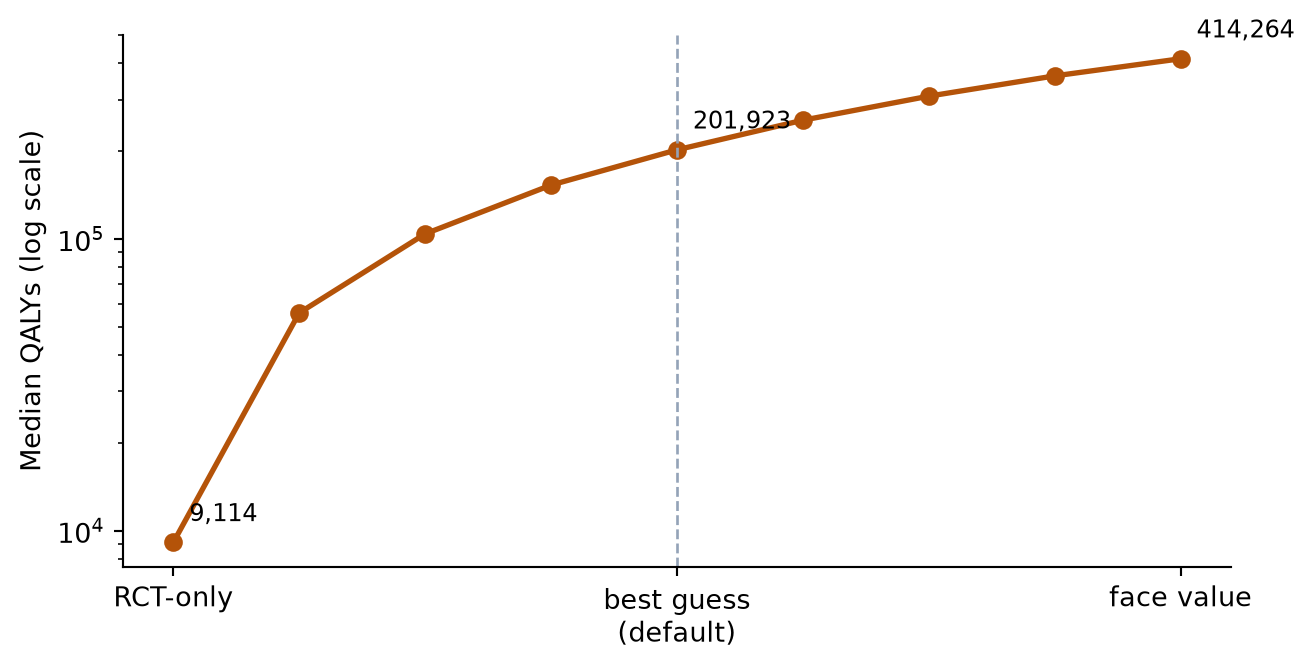

In [6]:
import matplotlib.pyplot as plt
from msqaly import load_params, run

def stance_median(s_val, n=100_000):
    p = load_params()
    for name, t in p["evidence_tiers"].items():
        base = t["mean"]
        floor = base if name == "randomized" else 0.01
        m = floor + (s_val/0.5)*(base-floor) if s_val <= 0.5 else base + ((s_val-0.5)/0.5)*(0.999-base)
        t["mean"] = min(max(m, 0.001), 0.999)
    r = run(p, n=n, seed=0)
    return float(np.median(np.asarray(r.total_qalys)))

grid = [0.0, 0.125, 0.25, 0.375, 0.5, 0.625, 0.75, 0.875, 1.0]
meds = [stance_median(s_val) for s_val in grid]

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(grid, meds, marker="o", color="#b45309", lw=2)
ax.axvline(0.5, color="#94a3b8", ls="--", lw=1)
ax.set_yscale("log")
ax.set_xticks([0, 0.5, 1.0])
ax.set_xticklabels(["RCT-only", "best guess\n(default)", "face value"])
ax.set_ylabel("Median QALYs (log scale)")
for s_val, m in [(0.0, meds[0]), (0.5, meds[4]), (1.0, meds[-1])]:
    ax.annotate(f"{m:,.0f}", (s_val, m), textcoords="offset points", xytext=(6, 8), fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

F_rct = f"{meds[0]:,.0f}"
F_face = f"{meds[-1]:,.0f}"

The dominant sensitivity is not a parameter but a philosophy. At the near-RCT-only floor — non-randomized tiers shrunk to a credibility mean of 0.01, the randomized tier kept at its drafted mean — the median collapses to 9,114 QALYs, dominated by the randomized-tier mental-health bucket; at near face value (all tier means 0.999) it rises to 414,264 (@fig-stance). That 45-fold range exceeds the spread from any single distributional parameter — though structural choices can move the headline more: with no geographic repricing at all, every health dollar at U.S. anchors, the median is roughly 70,000 (the pre-correction model in the §5.3 table), so the routing assumption alone spans ~3× — and the gap between the face-value and best-guess estimates is a direct reading of how much of the estimated impact rests on evidence below randomized or strong quasi-experimental identification standards. The Spearman tornado (@fig-tornado) tells the same story within the default stance: the top three drivers are the global-health allocation share, the realization factor, and global-health credibility.

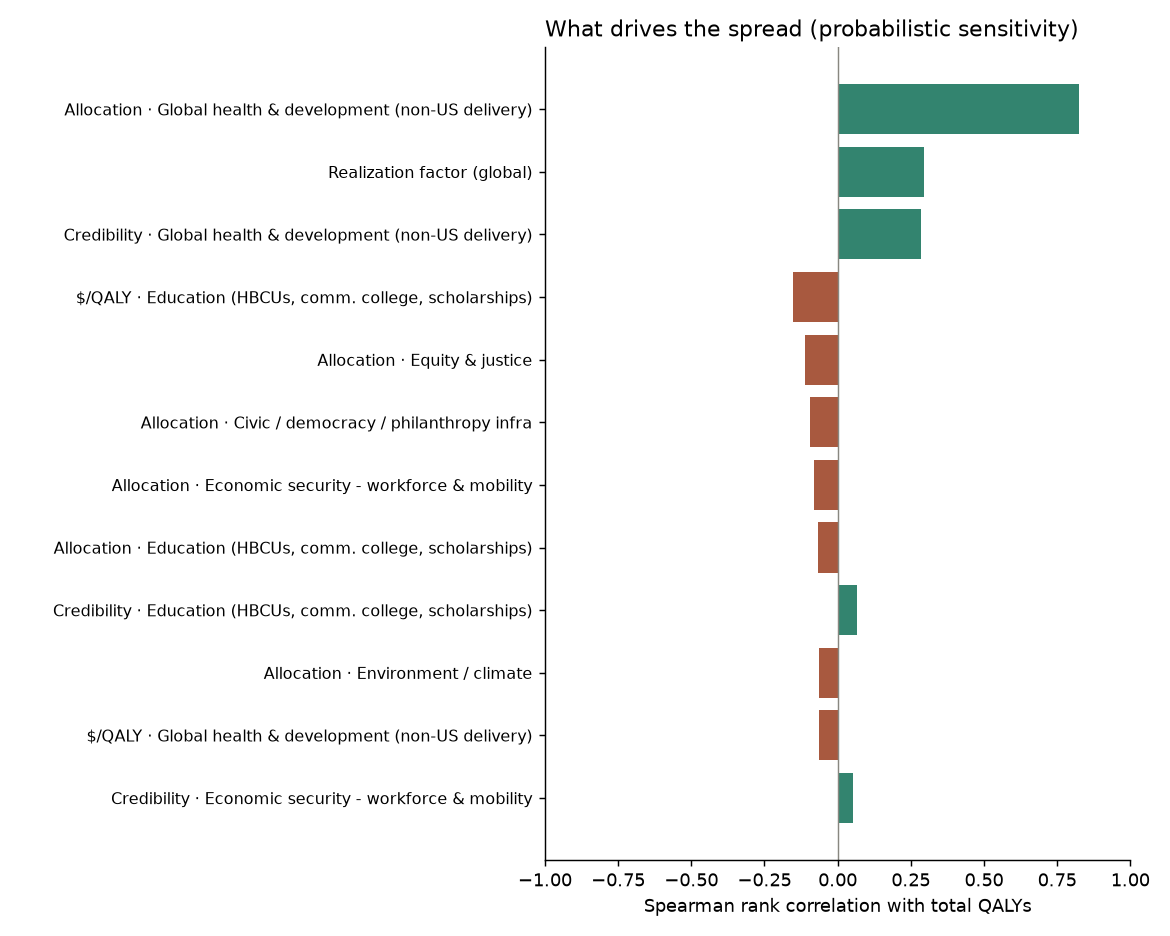

## The audit moved the headline by less than 2%

The geography audit is the largest data correction the model has absorbed since publication, and its effect is small: recentering the allocation on audited service geographies moved the abroad share from 4.93% to 4.82%, the median from about 205,000 to 201,923, and the blended figure from about \$148,000 to \$150,067 per QALY. Both allocations ship with the model, the browser version exposes them as a version toggle, and the pre-audit parameters remain pinned at tag `v2026.07.20` (audited: `v2026.07.22`).

## Corrections history

The model reached this state through a series of public revisions — counting a revision as a committed change that moved the headline — and the trajectory is itself evidence about the method. As recorded in the repository history:

| Change | Median before → after | Caught by |
|------------------------|------------------------|------------------------|
| Cross-model review: dollar vintages normalized, a life-year→QALY conversion made explicit, frontier benchmark re-derived, one citation re-attributed | ~98,000 → ~87,000 | second model family |
| Allocation replaced with the derivation from Scott’s own gift database | ~87,000 → ~70,000 | author + model |
| Health dollars had been priced at U.S. anchors regardless of delivery location | ~70,000 → ~205,000 | a reader |
| Two-model geography audit of “global”-listed organizations (tags v2026.07.20 → v2026.07.22) | ~205,000 → 202,000 | model audit |

Every correction is documented in the repository and summarized on the public tool; the detector column is the record, and none of these was caught by the author unaided.

# Construction and auditability

The model was built with a frontier language model (Anthropic’s Claude), with the author reviewing every parameter and assumption; adversarial review by a second model family (OpenAI’s), plus reader corrections, produced the revision history above. Three mechanisms make the result checkable rather than merely stated. Parameters live in one typed file in which every value carries its unit, dollar vintage, and inline citation, machine-validated at load; an annotated bibliography maps each quantitative input to its primary source and price-level conversion. Sync tests force the published web parameters, allocation shares, and geography exports to equal fresh derivations from the committed data snapshots, and the body of this manuscript interpolates its model-derived numbers from those same artifacts at render time (the abstract’s figures are typed copies of the interpolated values; externally sourced constants carry citations). And the audit trail is data: the 990 match audit ships as its applied per-row overlay, and the 50-organization geography audit ships with per-organization sources and confidence grades — both applied by the pipeline rather than folded silently into parameters.

The browser implementation is a checked TypeScript port that reruns the full Monte Carlo client-side; every figure in this paper can be reproduced, and every assumption overridden, at [maxghenis.com/mackenzie-scott-qaly](https://maxghenis.com/mackenzie-scott-qaly). The repository, including this manuscript’s source, is at [github.com/MaxGhenis/mackenzie-scott-qaly](https://github.com/MaxGhenis/mackenzie-scott-qaly).

# Limitations

The credibility tiers and realization distribution are judgment priors with no literature calibration; the ordering is defensible, the levels are not measured, and the stance sweep is the honest bound on their influence. The QALY lens counts only health, so the estimate is a partial accounting that omits both the non-health benefits where Scott concentrates — education, mobility, equity — and any possible harms; it is not a floor on total wellbeing. Credibility shrinks toward zero but never below it, so the model places no mass on harmful giving; the closest available zero scenario is the near-RCT-only stance floor, which drives unsupported archetypes to ~1% credit. Allocation splits each organization’s dollars equally across its focus areas and service locations; both are coarse, and the geography audit covers only the 50 largest “global”-listed organizations. Realization is one global draw, so it cannot vary by cause. Archetype anchors treat heterogeneous organizations as draws from one distribution. Within each cause, delivery regions are priced identically, so the geographic decomposition exposes assumptions rather than measuring regional differences. The undisclosed third of dollars is imputed from a fitted elasticity, not observed. The routed global-health bucket prices its unattributable and high-income-region dollars — roughly a fifth of the bucket — at low-and-middle-income anchors, an upward-bias channel. Several cost priors average over mixed null-and-positive evidence before the credibility discount applies, so the two-multiplier separation of doubts is imperfect at those boundaries. The Dirichlet allocation spread is a subjective prior; uncertainty from the elasticity fit, unmatched filings, the focus-area crosswalk, and the geography audit is not propagated. Allocation shares are derived in nominal dollars and applied to the real total; re-deriving in real dollars moves shares by hundredths of a percentage point. The geography audit’s scalar U.S. shares and regional decompositions were reconciled separately and can differ by fractions of a point per organization. Finally, several anchors rest on a small number of quasi-experimental papers whose external validity to Scott’s grantees is exactly what the realization factor is guessing at.

# Conclusion

Measured in health, MacKenzie Scott’s \$26 billion buys an estimated median of about 202,000 quality-adjusted life-years — several times its cost under the government’s own regulatory valuation — and most of that estimated health comes from the twentieth of her dollars funding health and development delivered abroad. The number is a model output under stated priors, not a fact, and the model’s most important output is not the point estimate but the machinery around it: explicit evidence weights, a 45-fold stance range that any reader can traverse, versioned corrections, and audits committed as data. Portfolio-scale philanthropy is measurable in outcomes without waiting for donors to publish outcome data — their own gift lists, recipients’ tax filings, and the published causal literature suffice — and the same machinery applies to any large giver whose public disclosures carry comparable gift-level allocation and geography fields. The invitation of the interactive version is the paper’s real conclusion: disagree with a parameter, move it, and watch what survives.

# Acknowledgments

I thank readers on LinkedIn and the EA Forum whose corrections materially improved the model, including the reader who identified the original mispricing of internationally delivered health dollars. The model, audits, and this manuscript were built with Anthropic’s Claude, with additional adversarial review by OpenAI models; all judgments and errors are mine. This is a personal research project and does not represent the views of PolicyEngine or the Axiom Foundation. Neither I nor those organizations have received funding from MacKenzie Scott or Yield Giving.

# References